In [13]:
import numpy as nm
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/kaggle/input/mall-customers/Mall_Customers.csv')

df = df.rename(columns={'Genre': 'Gender'})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

x_all = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

kmeans_unscaled = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_unscaled = kmeans_unscaled.fit_predict(x_all)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[['Gender', 'Annual Income (k$)', 'Spending Score (1-100)']])

x_scaled_partial = nm.column_stack((df['Age'].values, scaled_features))

kmeans_scaled = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_scaled = kmeans_scaled.fit_predict(x_scaled_partial)


df['Cluster_Unscaled'] = y_unscaled
df['Cluster_Scaled'] = y_scaled

print("Comparison of first 5 rows:")
print(df.head())

print("\n--- Average Age per Cluster (Scaled Scenario) ---")
print(df.groupby('Cluster_Scaled')['Age'].mean())


Comparison of first 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       0   19                  15                      39   
1           2       0   21                  15                      81   
2           3       1   20                  16                       6   
3           4       1   23                  16                      77   
4           5       1   31                  17                      40   

   Cluster_Unscaled  Cluster_Scaled  
0                 2               2  
1                 2               2  
2                 0               2  
3                 2               2  
4                 0               1  

--- Average Age per Cluster (Scaled Scenario) ---
Cluster_Scaled
0    63.535714
1    31.258621
2    21.400000
3    49.439024
4    39.242424
Name: Age, dtype: float64


In [14]:
import pandas as pd
import numpy as nm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}
df = pd.DataFrame(data)

df['vehicle_type_encoded'] = df['vehicle_type'].astype('category').cat.codes

x_all = df[['mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type_encoded']].values

kmeans_unscaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster_Unscaled'] = kmeans_unscaled.fit_predict(x_all)

scaler = StandardScaler()

features_to_scale = df[['mileage', 'fuel_efficiency', 'maintenance_cost']]
scaled_features = scaler.fit_transform(features_to_scale)

x_scaled = nm.column_stack((scaled_features, df['vehicle_type_encoded'].values))

kmeans_scaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster_Scaled'] = kmeans_scaled.fit_predict(x_scaled)

print("Fleet Segmentation Results:")
print(df[['vehicle_type', 'mileage', 'Cluster_Unscaled', 'Cluster_Scaled']])


Fleet Segmentation Results:
  vehicle_type  mileage  Cluster_Unscaled  Cluster_Scaled
0          SUV   150000                 2               2
1        Sedan   120000                 2               2
2        Truck   250000                 1               1
3    Hatchback    80000                 0               0
4        Sedan   100000                 0               2
5        Truck   220000                 1               1
6          SUV   180000                 2               2
7        Truck   300000                 1               1
8    Hatchback    75000                 0               0
9          SUV   280000                 1               1


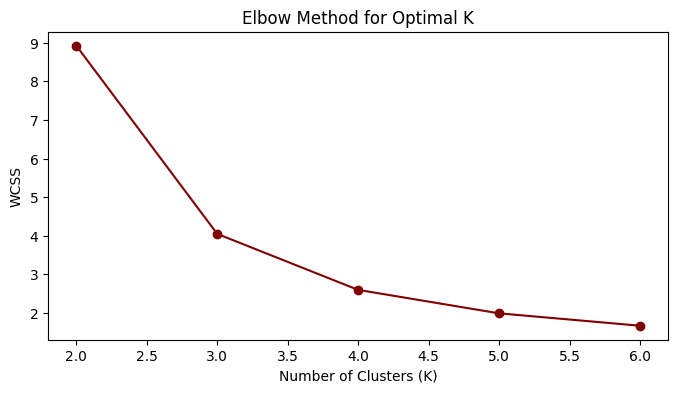

--- Final Student Segments ---
    student_id  GPA  study_hours  attendance_rate  Cluster
0          101  3.8           40               95        0
1          102  2.1           10               60        2
2          103  3.5           35               90        0
3          104  2.8           20               75        1
4          105  3.9           45               98        0
5          106  1.5            5               40        2
6          107  3.2           30               85        0
7          108  2.5           15               70        1
8          109  3.7           38               92        0
9          110  1.9           12               55        2
10         111  3.0           25               80        1
11         112  2.4           18               65        1


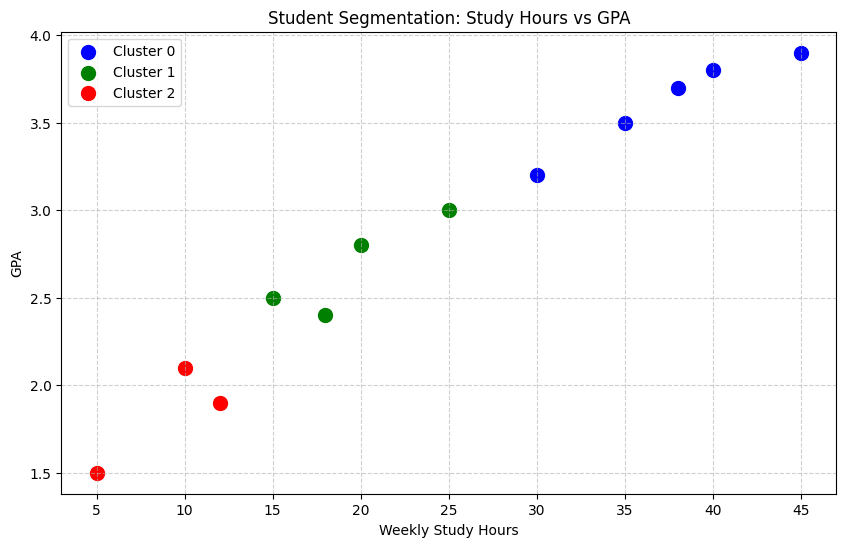

In [15]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112],
    'GPA': [3.8, 2.1, 3.5, 2.8, 3.9, 1.5, 3.2, 2.5, 3.7, 1.9, 3.0, 2.4],
    'study_hours': [40, 10, 35, 20, 45, 5, 30, 15, 38, 12, 25, 18],
    'attendance_rate': [95, 60, 90, 75, 98, 40, 85, 70, 92, 55, 80, 65]
}
df = pd.DataFrame(data)

x = df[['GPA', 'study_hours', 'attendance_rate']].values

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

wcss_list = []
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss_list.append(kmeans.inertia_)

mtp.figure(figsize=(8, 4))
mtp.plot(range(2, 7), wcss_list, marker='o', color='maroon')
mtp.title('Elbow Method for Optimal K')
mtp.xlabel('Number of Clusters (K)')
mtp.ylabel('WCSS')
mtp.show()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)

print("--- Final Student Segments ---")
print(df[['student_id', 'GPA', 'study_hours', 'attendance_rate', 'Cluster']])

mtp.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red', 'purple', 'orange']

for i in range(optimal_k):
    mtp.scatter(df[df['Cluster'] == i]['study_hours'],
                df[df['Cluster'] == i]['GPA'],
                s=100, c=colors[i], label=f'Cluster {i}')

mtp.title('Student Segmentation: Study Hours vs GPA')
mtp.xlabel('Weekly Study Hours')
mtp.ylabel('GPA')
mtp.legend()
mtp.grid(True, linestyle='--', alpha=0.6)
mtp.show()
